# **NSynth Instrument Classification**
This notebook implements a complete pipeline for musical instrument classification using the NSynth dataset.

The main objectives are:

- Analyze the NSynth dataset  
- Extract spectral representations from the audio  
- Train a CNN for multiclass classification  
- Evaluate the model’s performance  
- Analyze errors and draw academic conclusions

---

# Dataset

Datasets used:

- NSynth Train Set
- NSynth Test Set

Characteristics:

- Mono audio
- Sample rate: 16 kHz
- Single instrument notes
- Balanced and clean dataset

Instrument classes:

| ID | Instrument |
|---|---|
| 0 | bass |
| 1 | brass |
| 2 | flute |
| 3 | guitar |
| 4 | keyboard |
| 5 | mallet |
| 6 | organ |
| 7 | reed |
| 8 | string |
| 9 | synth_lead |
| 10 | vocal |

In [ ]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

### **Loading and Preprocessing Data**
This section is dedicated to loading the raw NSynth dataset, which includes audio samples and their corresponding categorical labels (`examples.json`). The goal is to prepare this data for subsequent model training by defining paths and structuring the metadata. This section defines the base directory where the NSynth dataset is stored and then constructs the full file paths for the validation and test subsets.

In [ ]:
BASE_PATH = "C:/Users/Daniel/Desktop"

VALID_PATH = os.path.join(
    BASE_PATH,
    "nsynth-valid-subset"
)

TEST_PATH = os.path.join(
    BASE_PATH,
    "nsynth-test-subset"
)

VALID_AUDIO_PATH = os.path.join(
    VALID_PATH,
    "audio"
)

TEST_AUDIO_PATH = os.path.join(
    TEST_PATH,
    "audio"
)

VALID_JSON_PATH = os.path.join(
    VALID_PATH,
    "examples.json"
)

TEST_JSON_PATH = os.path.join(
    TEST_PATH,
    "examples.json"
)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Metadata Loading
This section loads the NSynth metadata JSON files for the validation and test sets. The metadata contains sample IDs and instrument labels, which will be used to build the dataset.

In [ ]:
with open(VALID_JSON_PATH, "r") as f:
    valid_metadata = json.load(f)

with open(TEST_JSON_PATH, "r") as f:
    test_metadata = json.load(f)

print("Train samples:", len(valid_metadata))
print("Test samples:", len(test_metadata))

Train samples: 7957
Test samples: 3333


## Dataframe Construction
This cell creates structured Pandas DataFrames for both the validation and test datasets. Each DataFrame row represents an audio sample, consolidating its unique ID, instrument family (categorical label), and the full path to its audio file. This structured format facilitates easier data manipulation, filtering, and inspection throughout the preprocessing pipeline.

In [ ]:
def build_dataframe(metadata, audio_path):

    rows = []

    for key, value in metadata.items():

        rows.append({

            "id": key,

            "instrument_family":
                value["instrument_family_str"],

            "audio_path":
                os.path.join(audio_path, key + ".wav")
        })

    return pd.DataFrame(rows)

valid_df = build_dataframe(
    valid_metadata,
    VALID_AUDIO_PATH
)

test_df = build_dataframe(
    test_metadata,
    TEST_AUDIO_PATH
)

valid_df.head()

,id,instrument_family,audio_path
0,keyboard_electronic_078-056-100,keyboard,C:/Users/Daniel/Desktop\nsynth-valid-subset\au...
1,keyboard_acoustic_004-071-075,keyboard,C:/Users/Daniel/Desktop\nsynth-valid-subset\au...
2,keyboard_electronic_098-065-127,keyboard,C:/Users/Daniel/Desktop\nsynth-valid-subset\au...
3,keyboard_electronic_069-033-075,keyboard,C:/Users/Daniel/Desktop\nsynth-valid-subset\au...
4,keyboard_electronic_001-092-050,keyboard,C:/Users/Daniel/Desktop\nsynth-valid-subset\au...


## Simple EDA
Here we perform a simple EDA to check for an imbalanced dataset and to take a look at the spectrograms generated.

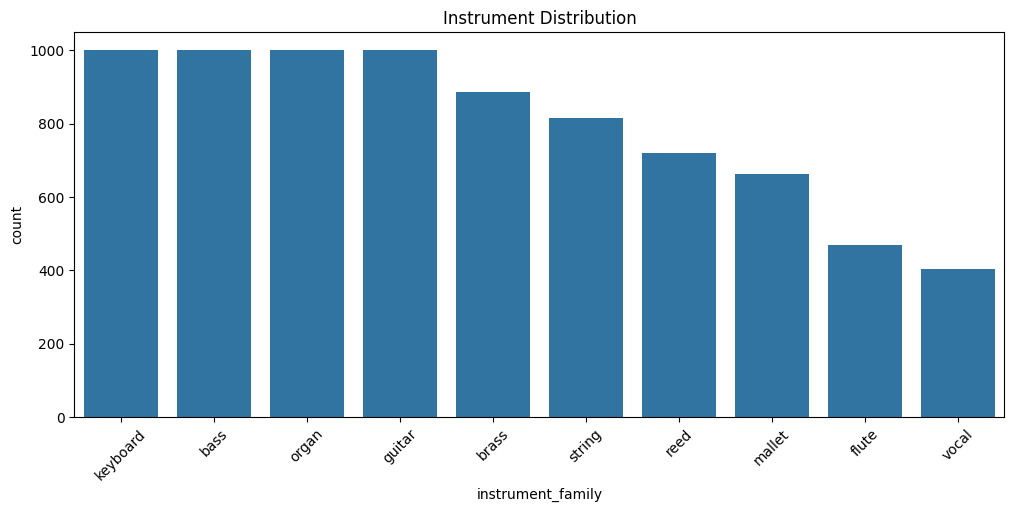

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=valid_df,
    x="instrument_family",
    order=valid_df["instrument_family"]
            .value_counts()
            .index
)

plt.xticks(rotation=45)

plt.title("Instrument Distribution")

plt.show()

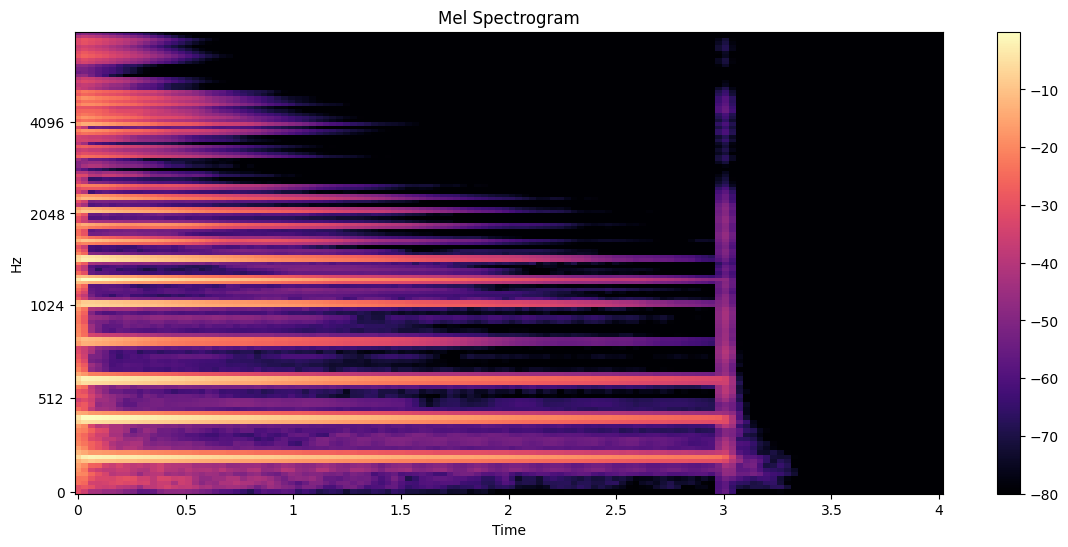

In [ ]:
# Sample spectrogram
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(14,6))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

## Label Encoding
Here, `sklearn.preprocessing.LabelEncoder` is used to transform the categorical `instrument_family` names (e.g., 'keyboard', 'guitar') into numerical integer labels (e.g., 0, 1, 2...). This conversion is a necessary step, as neural networks, particularly when using loss functions like `CrossEntropyLoss`, require target labels to be in an integer format rather than string representations.

In [ ]:
# LABEL ENCODING
label_encoder = LabelEncoder()

valid_df["label"] = label_encoder.fit_transform(
    valid_df["instrument_family"]
)

test_df["label"] = label_encoder.transform(
    test_df["instrument_family"]
)

NUM_CLASSES = len(
    label_encoder.classes_
)

print("Classes:", NUM_CLASSES)

print(label_encoder.classes_)

Classes: 10
['bass' 'brass' 'flute' 'guitar' 'keyboard' 'mallet' 'organ' 'reed'
 'string' 'vocal']


## Custom Dataset and Preprocessing
The `NSynthDataset` class is a custom PyTorch `Dataset` implementation designed to handle the loading and preprocessing of audio data. For each sample, it loads the audio, ensures a consistent length through padding or truncation, generates a Mel spectrogram (a frequency-time representation), converts it to a decibel scale for better dynamic range, normalizes the features, and finally converts them into PyTorch tensors suitable for model input. This encapsulates all the necessary transformations for batch processing.

In [ ]:
SAMPLE_RATE = 16000
DURATION = 4

SAMPLES = SAMPLE_RATE * DURATION

class NSynthDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(
            drop=True
        )

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        y, sr = librosa.load(
            row["audio_path"],
            sr=SAMPLE_RATE
        )

        # padding / truncation
        if len(y) < SAMPLES:

            y = np.pad(
                y,
                (0, SAMPLES - len(y))
            )

        else:

            y = y[:SAMPLES]

        # mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # normalization
        mel_db = (
            mel_db - mel_db.mean()
        ) / mel_db.std()

        mel_db = torch.tensor(
            mel_db
        ).float()

        mel_db = mel_db.unsqueeze(0)

        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return mel_db, label

## DataLoaders
PyTorch `DataLoader` objects are created from the `NSynthDataset` instances. These DataLoaders manage the efficient loading of data in mini-batches, which is essential for training neural networks. The `train_loader` is configured to `shuffle` the data at each epoch to improve generalization, while the `test_loader` maintains the original order, which is important for consistent evaluation.

In [ ]:
train_dataset = NSynthDataset(valid_df)

test_dataset = NSynthDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## CNN Model Architecture
This cell defines the `AudioCNN` model, a Convolutional Neural Network specifically designed for classifying audio spectrograms. The model consists of sequential convolutional layers (`nn.Conv2d`) for hierarchical feature extraction, interspersed with batch normalization (`nn.BatchNorm2d`), activation functions (`nn.ReLU`), and max-pooling layers (`nn.MaxPool2d`) to reduce dimensionality. These feature extraction layers are followed by a fully connected classifier (`nn.Linear`) that maps the learned features to the final instrument class predictions.

In [ ]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 7,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

model = AudioCNN(
    NUM_CLASSES
).to(DEVICE)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## Training Configuration
Set the loss function, optimizer, and number of training epochs. `CrossEntropyLoss` is used for classification, and Adam is a robust optimizer for this type of model.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 5

## Training Loop
This loop trains the model for several epochs. For each batch, it computes predictions, calculates loss, performs backpropagation, updates weights, and tracks training loss and accuracy.

In [ ]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    running_correct = 0
    total = 0

    for x, y in tqdm(train_loader):

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(
            outputs,
            y
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(
            outputs,
            1
        )

        running_correct += (
            preds == y
        ).sum().item()

        total += y.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = running_correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

100%|██████████| 249/249 [02:10<00:00,  1.91it/s]


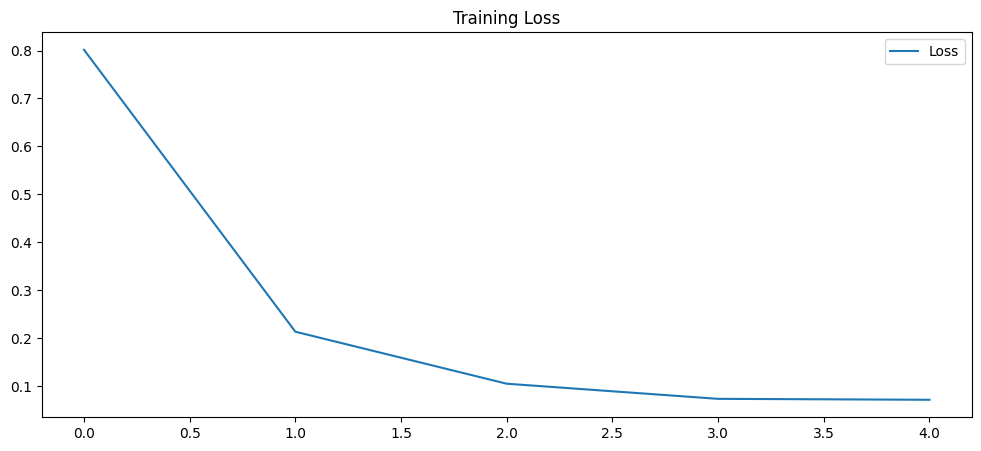

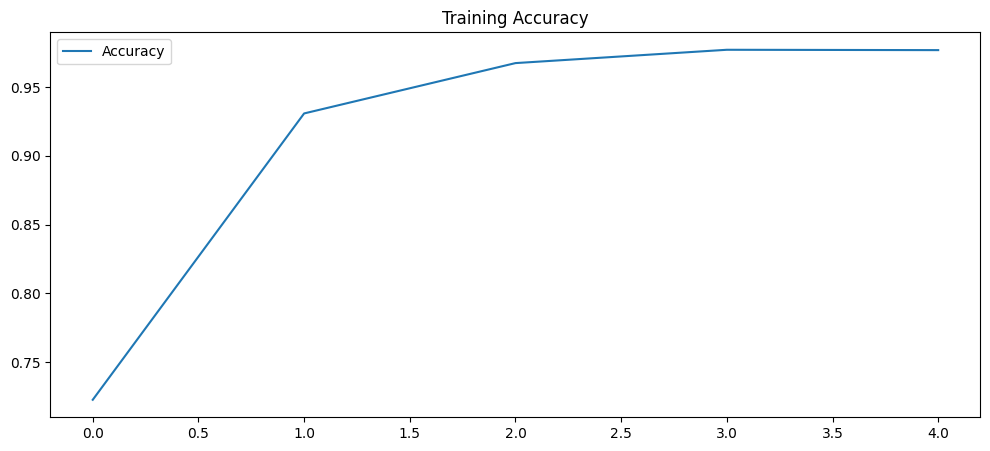

In [ ]:
# Training curves
plt.figure(figsize=(12,5))

plt.plot(
    train_losses,
    label="Loss"
)

plt.legend()

plt.title("Training Loss")

plt.show()

# ---------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    train_accuracies,
    label="Accuracy"
)

plt.legend()

plt.title("Training Accuracy")

plt.show()

## Evaluation and Metrics
Following the training phase, this section evaluates the performance of the trained CNN model on the unseen test dataset. It calculates key performance indicators such as overall accuracy and the weighted F1-score, providing a single metric for overall performance. Furthermore, a detailed `classification_report` is generated, offering per-class precision, recall, and F1-score, along with a visual `confusion_matrix` to identify specific misclassification patterns between instrument classes.

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        outputs = model(x)

        _, preds = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            y.numpy()
        )

In [ ]:
acc = accuracy_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("\nTEST RESULTS")

print(f"Accuracy: {acc:.4f}")

print(f"F1-score: {f1:.4f}")


TEST RESULTS
Accuracy: 0.9952
F1-score: 0.9952


In [ ]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        bass       1.00      1.00      1.00       500
       brass       1.00      1.00      1.00       269
       flute       0.99      1.00      1.00       180
      guitar       1.00      0.98      0.99       500
    keyboard       1.00      0.99      0.99       500
      mallet       0.98      1.00      0.99       202
       organ       1.00      1.00      1.00       500
        reed       0.99      1.00      1.00       235
      string       0.99      1.00      1.00       306
       vocal       1.00      1.00      1.00       141

    accuracy                           1.00      3333
   macro avg       0.99      1.00      1.00      3333
weighted avg       1.00      1.00      1.00      3333



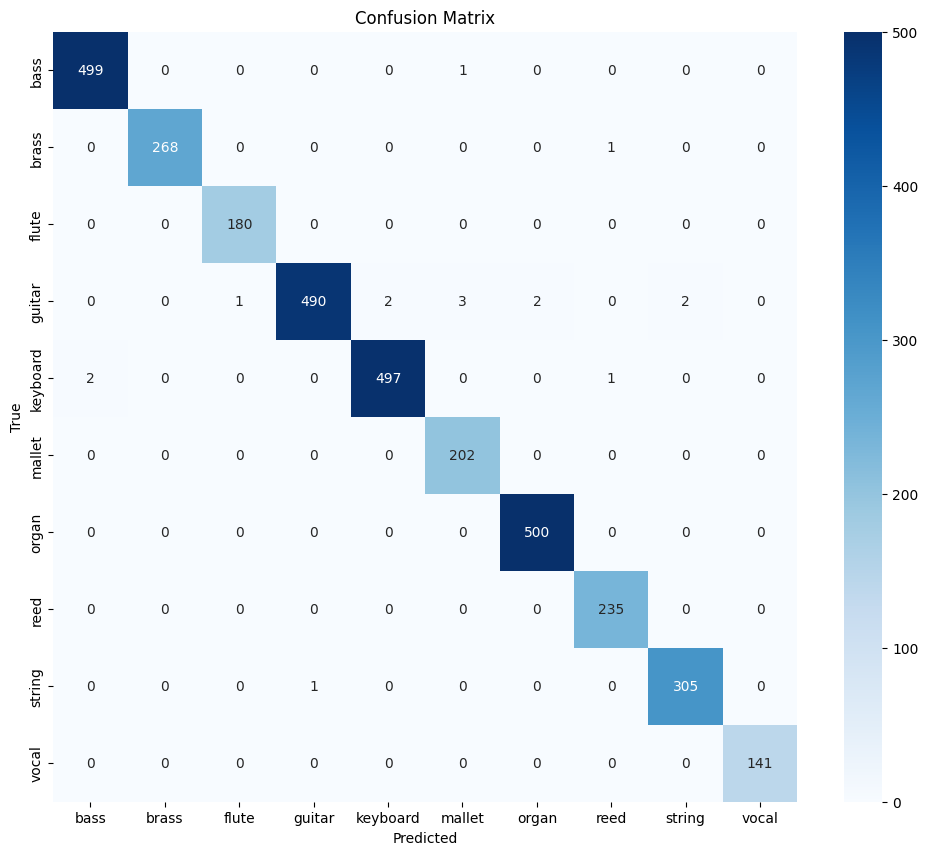

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# SAVE MODEL
torch.save(
    model.state_dict(),
    "nsynth_cnn.pth"
)

print("Model saved")


Model saved.


## Conclusions

The CNN model achieved excellent performance on the NSynth instrument classification task, as indicated by an overall accuracy of 0.9952 and a weighted F1-score of 0.9952 on the test set. The classification report further highlights strong per-class performance, with most instrument families showing perfect or near-perfect precision, recall, and F1-scores. The confusion matrix visually confirms the model's ability to accurately distinguish between different instrument classes, with very few misclassifications.

This high performance suggests that the Mel spectrogram features, combined with the designed CNN architecture, are highly effective at capturing the distinct sonic characteristics of the NSynth dataset's instrument families.